# Working with Sequences
:label:`sec_sequence`

Up until now, we have focused on models whose inputs
consisted of a single feature vector $\mathbf{x} \in \mathbb{R}^d$.
The main change of perspective when developing models
capable of processing sequences is that we now
focus on inputs that consist of an ordered list
of feature vectors $\mathbf{x}_1, \dots, \mathbf{x}_T$,
where each feature vector $\mathbf{x}_t$ is
indexed by a time step $t \in \mathbb{Z}^+$
lying in $\mathbb{R}^d$.

Some datasets consist of a single massive sequence.
Consider, for example, the extremely long streams
of sensor readings that might be available to climate scientists.
In such cases, we might create training datasets
by randomly sampling subsequences of some predetermined length.
More often, our data arrives as a collection of sequences.
Consider the following examples:
(i) a collection of documents,
each represented as its own sequence of words,
and each having its own length $T_i$;
(ii) sequence representation of
patient stays in the hospital,
where each stay consists of a number of events
and the sequence length depends roughly
on the length of the stay.


Previously, when dealing with individual inputs,
we assumed that they were sampled independently
from the same underlying distribution $P(X)$.
While we still assume that entire sequences
(e.g., entire documents or patient trajectories)
are sampled independently,
we cannot assume that the data arriving
at each time step are independent of each other.
For example, the words that likely to appear later in a document
depend heavily on words occurring earlier in the document.
The medicine a patient is likely to receive
on the 10th day of a hospital visit
depends heavily on what transpired
in the previous nine days.

This should come as no surprise.
If we did not believe that the elements in a sequence were related,
we would not have bothered to model them as a sequence in the first place.
Consider the usefulness of the auto-fill features
that are popular on search tools and modern email clients.
They are useful precisely because it is often possible
to predict (imperfectly, but better than random guessing)
what the likely continuations of a sequence might be,
given some initial prefix.
For most sequence models,
we do not require independence,
or even stationarity, of our sequences.
Instead, we require only that
the sequences themselves are sampled
from some fixed underlying distribution
over entire sequences.

This flexible approach allows for such phenomena
as (i) documents looking significantly different
at the beginning than at the end;
or (ii) patient status evolving either
towards recovery or towards death
over the course of a hospital stay;
or (iii) customer taste evolving in predictable ways
over the course of continued interaction with a recommender system.


We sometimes wish to predict a fixed target $y$
given sequentially structured input
(e.g., sentiment classification based on a movie review).
At other times, we wish to predict a sequentially structured target
($y_1, \ldots, y_T$)
given a fixed input (e.g., image captioning).
Still other times, our goal is to predict sequentially structured targets
based on sequentially structured inputs
(e.g., machine translation or video captioning).
Such sequence-to-sequence tasks take two forms:
(i) *aligned*: where the input at each time step
aligns with a corresponding target (e.g., part of speech tagging);
(ii) *unaligned*: where the input and target
do not necessarily exhibit a step-for-step correspondence
(e.g., machine translation).

Before we worry about handling targets of any kind,
we can tackle the most straightforward problem:
unsupervised density modeling (also called *sequence modeling*).
Here, given a collection of sequences,
our goal is to estimate the probability mass function
that tells us how likely we are to see any given sequence,
i.e., $p(\mathbf{x}_1, \ldots, \mathbf{x}_T)$.


# 序列处理
:label:`sec_sequence`

到目前为止，我们主要关注输入为单个特征向量$\mathbf{x} \in \mathbb{R}^d$的模型。当开发能够处理序列的模型时，主要视角变化在于我们现在关注由有序特征向量列表$\mathbf{x}_1, \dots, \mathbf{x}_T$组成的输入，其中每个特征向量$\mathbf{x}_t$由时间步$t \in \mathbb{Z}^+$索引，且$\mathbf{x}_t \in \mathbb{R}^d$。

有些数据集由单个超长序列组成。例如气候科学家可能获得的极长传感器读数流。这种情况下，我们可以通过随机采样预定长度的子序列来创建训练数据集。更常见的是，我们的数据以序列集合的形式到达。考虑以下例子：
(i) 文档集合，每个文档表示为自己的单词序列，且各有长度$T_i$；
(ii) 医院患者住院记录的序列表示，每次住院包含若干事件，序列长度大致取决于住院时长。

之前处理单个输入时，我们假设它们是从相同基础分布$P(X)$中独立采样的。虽然我们仍然假设整个序列（如完整文档或患者轨迹）是独立采样的，但不能假设每个时间步到达的数据是相互独立的。例如文档后面可能出现的单词很大程度上取决于文档前面的单词。患者住院第10天可能接受的药物治疗很大程度上取决于前9天发生的情况。

这并不令人意外。如果我们不相信序列中的元素是相关的，一开始就不会将其建模为序列。考虑搜索工具和现代邮件客户端中流行的自动填充功能的有用性。它们之所以有用，正是因为给定某些初始前缀后，通常可以预测（虽不完美但优于随机猜测）序列可能的延续。对于大多数序列模型，我们不需要序列的独立性甚至平稳性，只需要序列本身是从某个固定基础序列分布中采样的即可。

这种灵活方法允许出现以下现象：
(i) 文档开头与结尾看起来显著不同；
(ii) 患者状态在住院期间向康复或死亡演变；
(iii) 客户在与推荐系统持续交互过程中口味以可预测方式演变。

有时我们希望基于序列化输入预测固定目标$y$（如基于影评的情感分类）。有时我们希望基于固定输入预测序列化目标（$y_1, \ldots, y_T$）（如图像描述生成）。还有些时候，我们的目标是基于序列化输入预测序列化目标（如机器翻译或视频字幕生成）。这类序列到序列任务有两种形式：
(i) *对齐*：每个时间步的输入与对应目标对齐（如词性标注）；
(ii) *未对齐*：输入与目标不一定呈现逐步对应关系（如机器翻译）。

在考虑如何处理任何类型的目标之前，我们可以先解决最直接的问题：无监督密度建模（也称为*序列建模*）。给定序列集合，我们的目标是估计概率质量函数，告诉我们看到任何给定序列的可能性，即$p(\mathbf{x}_1, \ldots, \mathbf{x}_T)$。

In [2]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

## Autoregressive Models


Before introducing specialized neural networks
designed to handle sequentially structured data,
let's take a look at some actual sequence data
and build up some basic intuitions and statistical tools.
In particular, we will focus on stock price data
from the FTSE 100 index (:numref:`fig_ftse100`).
At each *time step* $t \in \mathbb{Z}^+$, we observe
the price, $x_t$, of the index at that time.


![FTSE 100 index over about 30 years.](../img/ftse100.png)
:width:`400px`
:label:`fig_ftse100`


Now suppose that a trader would like to make short-term trades,
strategically getting into or out of the index,
depending on whether they believe
that it will rise or decline
in the subsequent time step.
Absent any other features
(news, financial reporting data, etc.),
the only available signal for predicting
the subsequent value is the history of prices to date.
The trader is thus interested in knowing
the probability distribution

$$P(x_t \mid x_{t-1}, \ldots, x_1)$$

over prices that the index might take
in the subsequent time step.
While estimating the entire distribution
over a continuously valued random variable
can be difficult, the trader would be happy
to focus on a few key statistics of the distribution,
particularly the expected value and the variance.
One simple strategy for estimating the conditional expectation

$$\mathbb{E}[(x_t \mid x_{t-1}, \ldots, x_1)],$$

would be to apply a linear regression model
(recall :numref:`sec_linear_regression`).
Such models that regress the value of a signal
on the previous values of that same signal
are naturally called *autoregressive models*.
There is just one major problem: the number of inputs,
$x_{t-1}, \ldots, x_1$ varies, depending on $t$.
In other words, the number of inputs increases
with the amount of data that we encounter.
Thus if we want to treat our historical data
as a training set, we are left with the problem
that each example has a different number of features.
Much of what follows in this chapter
will revolve around techniques
for overcoming these challenges
when engaging in such *autoregressive* modeling problems
where the object of interest is
$P(x_t \mid x_{t-1}, \ldots, x_1)$
or some statistic(s) of this distribution.

A few strategies recur frequently.
First of all,
we might believe that although long sequences
$x_{t-1}, \ldots, x_1$ are available,
it may not be necessary
to look back so far in the history
when predicting the near future.
In this case we might content ourselves
to condition on some window of length $\tau$
and only use $x_{t-1}, \ldots, x_{t-\tau}$ observations.
The immediate benefit is that now the number of arguments
is always the same, at least for $t > \tau$.
This allows us to train any linear model or deep network
that requires fixed-length vectors as inputs.
Second, we might develop models that maintain
some summary $h_t$ of the past observations
(see :numref:`fig_sequence-model`)
and at the same time update $h_t$
in addition to the prediction $\hat{x}_t$.
This leads to models that estimate not only $x_t$
with $\hat{x}_t = P(x_t \mid h_{t})$
but also updates of the form
$h_t = g(h_{t-1}, x_{t-1})$.
Since $h_t$ is never observed,
these models are also called
*latent autoregressive models*.

![A latent autoregressive model.](../img/sequence-model.svg)
:label:`fig_sequence-model`

To construct training data from historical data, one
typically creates examples by sampling windows randomly.
In general, we do not expect time to stand still.
However, we often assume that while
the specific values of $x_t$ might change,
the dynamics according to which each subsequent
observation is generated given the previous observations do not.
Statisticians call dynamics that do not change *stationary*.



## Sequence Models

Sometimes, especially when working with language,
we wish to estimate the joint probability
of an entire sequence.
This is a common task when working with sequences
composed of discrete *tokens*, such as words.
Generally, these estimated functions are called *sequence models*
and for natural language data, they are called *language models*.
The field of sequence modeling has been driven so much by natural language processing,
that we often describe sequence models as "language models",
even when dealing with non-language data.
Language models prove useful for all sorts of reasons.
Sometimes we want to evaluate the likelihood of sentences.
For example, we might wish to compare
the naturalness of two candidate outputs
generated by a machine translation system
or by a speech recognition system.
But language modeling gives us not only
the capacity to *evaluate* likelihood,
but the ability to *sample* sequences,
and even to optimize for the most likely sequences.

While language modeling might not, at first glance, look
like an autoregressive problem,
we can reduce language modeling to autoregressive prediction
by decomposing the joint density  of a sequence $p(x_1, \ldots, x_T)$
into the product of conditional densities
in a left-to-right fashion
by applying the chain rule of probability:

$$P(x_1, \ldots, x_T) = P(x_1) \prod_{t=2}^T P(x_t \mid x_{t-1}, \ldots, x_1).$$

Note that if we are working with discrete signals such as words,
then the autoregressive model must be a probabilistic classifier,
outputting a full probability distribution
over the vocabulary for whatever word will come next,
given the leftwards context.



### Markov Models
:label:`subsec_markov-models`


Now suppose that we wish to employ the strategy mentioned above,
where we condition only on the $\tau$ previous time steps,
i.e., $x_{t-1}, \ldots, x_{t-\tau}$, rather than
the entire sequence history $x_{t-1}, \ldots, x_1$.
Whenever we can throw away the history
beyond the previous $\tau$ steps
without any loss in predictive power,
we say that the sequence satisfies a *Markov condition*,
i.e., *that the future is conditionally independent of the past,
given the recent history*.
When $\tau = 1$, we say that the data is characterized
by a *first-order Markov model*,
and when $\tau = k$, we say that the data is characterized
by a $k^{\textrm{th}}$-order Markov model.
For when the first-order Markov condition holds ($\tau = 1$)
the factorization of our joint probability becomes a product
of probabilities of each word given the previous *word*:

$$P(x_1, \ldots, x_T) = P(x_1) \prod_{t=2}^T P(x_t \mid x_{t-1}).$$

We often find it useful to work with models that proceed
as though a Markov condition were satisfied,
even when we know that this is only *approximately* true.
With real text documents we continue to gain information
as we include more and more leftwards context.
But these gains diminish rapidly.
Thus, sometimes we compromise, obviating computational and statistical difficulties
by training models whose validity depends
on a $k^{\textrm{th}}$-order Markov condition.
Even today's massive RNN- and Transformer-based language models
seldom incorporate more than thousands of words of context.


With discrete data, a true Markov model
simply counts the number of times
that each word has occurred in each context, producing
the relative frequency estimate of $P(x_t \mid x_{t-1})$.
Whenever the data assumes only discrete values
(as in language),
the most likely sequence of words can be computed efficiently
using dynamic programming.


### The Order of Decoding

You may be wondering why we represented
the factorization of a text sequence $P(x_1, \ldots, x_T)$
as a left-to-right chain of conditional probabilities.
Why not right-to-left or some other, seemingly random order?
In principle, there is nothing wrong with unfolding
$P(x_1, \ldots, x_T)$ in reverse order.
The result is a valid factorization:

$$P(x_1, \ldots, x_T) = P(x_T) \prod_{t=T-1}^1 P(x_t \mid x_{t+1}, \ldots, x_T).$$


However, there are many reasons why factorizing text
in the same direction in which we read it
(left-to-right for most languages,
but right-to-left for Arabic and Hebrew)
is preferred for the task of language modeling.
First, this is just a more natural direction for us to think about.
After all we all read text every day,
and this process is guided by our ability
to anticipate which words and phrases
are likely to come next.
Just think of how many times you have completed
someone else's sentence.
Thus, even if we had no other reason to prefer such in-order decodings,
they would be useful if only because we have better intuitions
for what should be likely when predicting in this order.

Second, by factorizing in order,
we can assign probabilities to arbitrarily long sequences
using the same language model.
To convert a probability over steps $1$ through $t$
into one that extends to word $t+1$ we simply
multiply by the conditional probability
of the additional token given the previous ones:
$P(x_{t+1}, \ldots, x_1) = P(x_{t}, \ldots, x_1) \cdot P(x_{t+1} \mid x_{t}, \ldots, x_1)$.

Third, we have stronger predictive models
for predicting adjacent words than
words at arbitrary other locations.
While all orders of factorization are valid,
they do not necessarily all represent equally easy
predictive modeling problems.
This is true not only for language,
but for other kinds of data as well,
e.g., when the data is causally structured.
For example, we believe that future events cannot influence the past.
Hence, if we change $x_t$, we may be able to influence
what happens for $x_{t+1}$ going forward but not the converse.
That is, if we change $x_t$, the distribution over past events will not change.
In some contexts, this makes it easier to predict $P(x_{t+1} \mid x_t)$
than to predict $P(x_t \mid x_{t+1})$.
For instance, in some cases, we can find $x_{t+1} = f(x_t) + \epsilon$
for some additive noise $\epsilon$,
whereas the converse is not true :cite:`Hoyer.Janzing.Mooij.ea.2009`.
This is great news, since it is typically the forward direction
that we are interested in estimating.
The book by :citet:`Peters.Janzing.Scholkopf.2017` contains more on this topic.
We barely scratch the surface of it.


## Training

Before we focus our attention on text data,
let's first try this out with some
continuous-valued synthetic data.

(**Here, our 1000 synthetic data will follow
the trigonometric `sin` function,
applied to 0.01 times the time step.
To make the problem a little more interesting,
we corrupt each sample with additive noise.**)
From this sequence we extract training examples,
each consisting of features and a label.


## 自回归模型

在介绍专门处理序列数据的神经网络之前，我们先观察实际序列数据并建立基本统计工具。我们以FTSE 100指数（:numref:`fig_ftse100`）的股价数据为例，每个时间步$t \in \mathbb{Z}^+$观测指数价格$x_t$。

![FTSE 100指数约30年走势](../img/ftse100.png)
:width:`400px`
:label:`fig_ftse100`

假设交易者希望根据对后续走势的判断进行短期交易。在没有其他特征（新闻、财报数据等）的情况下，唯一可用的预测信号是历史价格序列。交易者需要知道条件概率分布：

$$P(x_t \mid x_{t-1}, \ldots, x_1)$$

虽然估计连续随机变量的完整分布较困难，但可以聚焦期望值和方差等关键统计量。简单策略是使用线性回归模型估计条件期望：

$$\mathbb{E}[(x_t \mid x_{t-1}, \ldots, x_1)]$$

这种将信号值回归到其历史值的模型称为*自回归模型*。主要挑战是输入数量$x_{t-1}, \ldots, x_1$随$t$变化，导致训练样本特征数不同。本章主要解决这类自回归建模问题，常用策略包括：

1. **窗口限制**：仅使用最近$\tau$个观测值$x_{t-1}, \ldots, x_{t-\tau}$，保证$t>\tau$时输入维度固定
2. **隐状态模型**：维护隐状态$h_t$总结历史信息，更新规则：
   $$\begin{aligned}
   \hat{x}_t &= P(x_t \mid h_t) \\
   h_t &= g(h_{t-1}, x_{t-1})
   \end{aligned}$$
   这类模型称为*隐式自回归模型*。

![隐式自回归模型](../img/sequence-model.svg)
:label:`fig_sequence-model`

从历史数据构建训练集时，通常随机采样窗口。虽然具体值$x_t$会变化，但假设生成后续观测的动态规律不变，统计学家称这种动态为*平稳性*。

## 序列模型

处理离散token序列（如文本）时，常需估计整个序列的联合概率，这类模型称为*序列模型*（自然语言处理中称*语言模型*）。通过概率链式法则可将联合密度分解为左到右的条件概率乘积：

$$P(x_1, \ldots, x_T) = P(x_1) \prod_{t=2}^T P(x_t \mid x_{t-1}, \ldots, x_1)$$

对于离散信号（如单词），自回归模型需输出词汇表上的完整概率分布。

### 马尔可夫模型
:label:`subsec_markov-models`

当仅依赖前$\tau$个时间步时（马尔可夫条件），$k$阶马尔可夫模型的联合概率分解为：

$$P(x_1, \ldots, x_T) = P(x_1) \prod_{t=2}^T P(x_t \mid x_{t-1}, \ldots, x_{t-\tau})$$

实际常使用近似马尔可夫模型，即使现代大规模语言模型也很少包含超过数千词的上下文。

### 解码顺序

虽然可以从任意方向分解概率，但按阅读顺序（多数语言从左到右）分解更合理，因为：
1. 更符合人类预测习惯
2. 允许逐步扩展序列概率
3. 对相邻词的预测通常更准确

因果性结构数据中，未来事件不影响过去，使得正向预测$P(x_{t+1} \mid x_t)$通常比逆向预测$P(x_t \mid x_{t+1})$更简单。如存在$x_{t+1} = f(x_t) + \epsilon$形式，而逆向关系不成立:cite:`Hoyer.Janzing.Mooij.ea.2009`。

## 训练

在聚焦文本数据前，我们先使用连续值合成数据进行实验。

(**生成1000个数据点，每个点应用0.01倍时间步的`sin`函数，并添加噪声干扰。**)从中提取特征和标签组成的训练样本。

In [3]:
class Data(d2l.DataModule):
    def __init__(self, batch_size=16, T=1000, num_train=600, tau=4):
        self.save_hyperparameters()
        self.time = torch.arange(1, T + 1, dtype=torch.float32)
        self.x = torch.sin(0.01 * self.time) + torch.randn(T) * 0.2

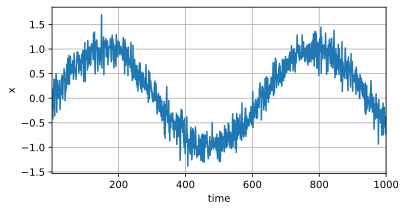

In [4]:
data = Data()
d2l.plot(data.time, data.x, 'time', 'x', xlim=[1, 1000], figsize=(6, 3))

In [5]:
class ChiData(d2l.DataModule):
    def __init__(self, batch_size=16, T=1000, num_train=600, tau=4):
        self.save_hyperparameters()
        self.time = torch.arange(1, T + 1, dtype=torch.float32)
        self.x = torch.sin(0.01 * self.time) + torch.randn(T) * 0.2

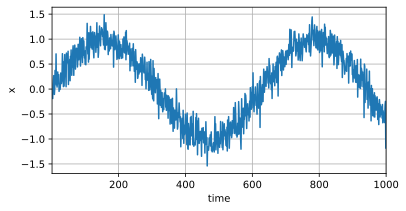

In [6]:
chi_data = ChiData()
d2l.plot(chi_data.time, chi_data.x, 'time', 'x', xlim=[1, 1000], figsize=(6,3))

To begin, we try a model that acts as if
the data satisfied a $\tau^{\textrm{th}}$-order Markov condition,
and thus predicts $x_t$ using only the past $\tau$ observations.
[**Thus for each time step we have an example
with label $y  = x_t$ and features
$\mathbf{x}_t = [x_{t-\tau}, \ldots, x_{t-1}]$.**]
The astute reader might have noticed that
this results in $1000-\tau$ examples,
since we lack sufficient history for $y_1, \ldots, y_\tau$.
While we could pad the first $\tau$ sequences with zeros,
to keep things simple, we drop them for now.
The resulting dataset contains $T - \tau$ examples,
where each input to the model has sequence length $\tau$.
We (**create a data iterator on the first 600 examples**),
covering a period of the sin function.


首先，我们尝试建立一个假设数据满足$\tau$阶马尔可夫条件的模型，即仅用过去$\tau$个观测值预测$x_t$。[**因此每个时间步的样本标签为$y = x_t$，特征向量为$\mathbf{x}_t = [x_{t-\tau}, \ldots, x_{t-1}]$。**] 细心的读者可能注意到，这将产生$1000-\tau$个有效样本——因为前$\tau$个时间步$y_1, \ldots, y_\tau$缺乏足够的历史数据。虽然可以用零填充前$\tau$个序列，但为保持简单性我们暂时直接删除它们。最终数据集包含$T - \tau$个样本，每个模型的输入序列长度固定为$\tau$。我们(**在前600个样本上创建数据迭代器**)，覆盖正弦函数的一个完整周期。

该代码段中`self.features = torch.stack(features, 1)`的核心作用是通过维度重组构建时间序列特征矩阵，具体实现以下三个关键功能：

1. **时间窗特征重组**：
   - 原始`features`列表包含$\tau$个形状为`[num_samples]`的张量
   - 每个张量对应不同起始点的历史窗口：
     ```python
     features[0] = x[0:T-tau]      # 第1个时间窗
     features[1] = x[1:T-tau+1]    # 第2个时间窗
     ...
     features[τ-1] = x[τ-1:T-1]    # 第τ个时间窗
     ```

2. **维度变换过程**：
   - 堆叠前：$\tau$个形状为`[T-τ]`的一维张量
   - 堆叠后：形状变为`[T-τ, τ]`的二维张量
   - 示例（设T=1000, τ=4）：
     ```
     原始特征列表：4个形状[996]的张量
     stack后矩阵：996个样本 × 4个时间步
     ```

3. **数据结构对齐**：
   | 维度 | 说明 | 典型RNN输入要求 |
   |------|------|----------------|
   | 维度0 | 样本数量(T-τ) | 批次维度 |
   | 维度1 | 时间步数(τ) | 序列长度 |
   | 维度2 | 特征维度(自动扩展) | 特征通道 |

   通过这种排列方式，可以直接作为RNN/LSTM等模型的输入，其期望的输入形状为`[序列长度, 批次大小, 特征维度]`（需配合`permute`进行维度调整）

该操作本质上创建了一个滑动窗口特征矩阵，使得每个样本的特征向量包含连续τ个时间步的历史观测值，满足时间序列模型对输入结构的严格要求。

关于`dim=1`的选择，需要从数据结构的底层实现来分析：

1. **原始数据形态**：
   - `self.x` 是形状为 `[T]` 的一维时间序列
   - 列表推导生成的特征矩阵数学表达为：
     $$
     \text{features} = \begin{bmatrix}
     x_0 & x_1 & \cdots & x_{T-\tau-1} \\
     x_1 & x_2 & \cdots & x_{T-\tau} \\
     \vdots & \vdots & \ddots & \vdots \\
     x_{\tau-1} & x_{\tau} & \cdots & x_{T-2}
     \end{bmatrix}^\top
     $$
     矩阵维度为 $(T-\tau) \times \tau$

2. **堆叠维度解析**：
   - 每个 `features[i]` 是形状为 `[T-τ]` 的行向量
   - `torch.stack(features, 1)` 的实际执行过程：
     ```python
     # 伪代码演示
     stacked = [
         [x[0], x[1], ..., x[τ-1]],          # 时间点t=0的特征向量
         [x[1], x[2], ..., x[τ]],            # 时间点t=1的特征向量
         ...
         [x[T-τ-1], x[T-τ], ..., x[T-2]]     # 时间点t=T-τ-1的特征向量
     ]
     ```
     通过dim=1将τ个行向量按列方向拼接

3. **维度可视化对比**：
   | 操作                 | 输入形状          | 输出形状         | 物理意义               |
   |----------------------|-------------------|------------------|------------------------|
   | `torch.stack(features, 0)` | [τ] × [T-τ]     | [τ, T-τ]        | 时间窗×原始序列（错误结构） |
   | `torch.stack(features, 1)` | [τ] × [T-τ]     | [T-τ, τ]        | 样本数×时间窗（正确结构） |

4. **PyTorch底层实现机制**：
   ```python
   # 实际执行时的维度转换
   features = [tensor_1d_1, tensor_1d_2, ..., tensor_1d_τ]  # 每个tensor_1d形状[T-τ]
   stacked = torch.stack(features, 1)  # 自动插入新维度，输出形状[T-τ, τ]
   ```
   这里的dim=1实际上是在(T-τ)个样本的维度后插入时间窗维度

该操作成功的关键在于PyTorch对一维张量堆叠的特殊处理：当堆叠一维张量时，会自动扩展出第二个维度，使得dim=1的指定实际上创建了特征维度。

In [7]:
@d2l.add_to_class(Data)
def get_dataloader(self, train):
    features = [self.x[i : self.T-self.tau+i] for i in range(self.tau)]
    self.features = torch.stack(features, 1)
    self.labels = self.x[self.tau:].reshape((-1, 1))
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader([self.features, self.labels], train, i)

In [8]:
@d2l.add_to_class(ChiData)
def get_dataloader(self, train):
    features = [self.x[i : self.T - self.tau + i] for i in range(self.tau)]
    self.features = torch.stack(features, 1)
    self.labels = self.x[self.tau:].reshape((-1, 1))
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader([self.features, self.labels], train, i)

In this example our model will be a standard linear regression.


在这个例子下，我们的模型是一个标准的线性回归

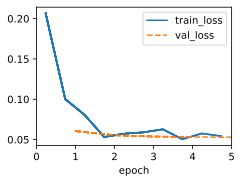

In [14]:
model = d2l.LinearRegression(lr=0.01)
trainer = d2l.Trainer(max_epochs=5)
trainer.fit(model, data)

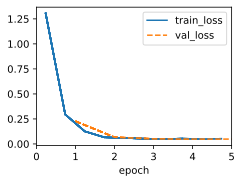

In [13]:
chi_model = d2l.LinearRegression(lr = 0.01)
chi_trainer = d2l.Trainer(max_epochs=5)
trainer.fit(chi_model, chi_data)

## Prediction

[**To evaluate our model, we first check
how well it performs at one-step-ahead prediction**].

## 预测

[**为了评估我们的模型，我们首先检查它在单步预测方面的表现**]

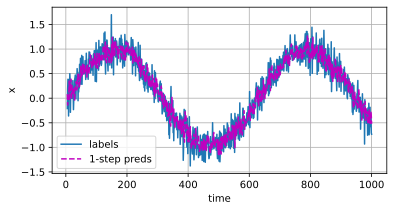

In [15]:
onestep_preds = model(data.features).detach().numpy()
d2l.plot(data.time[data.tau:], [data.labels, onestep_preds], 'time', 'x',
         legend=['labels', '1-step preds'], figsize=(6, 3))

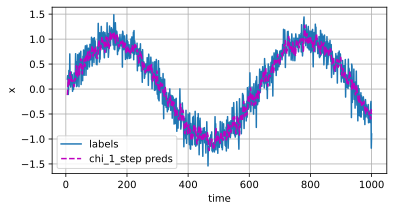

In [16]:
chi_onestep_preds = chi_model(chi_data.features).detach().numpy()
d2l.plot(chi_data.time[chi_data.tau:],[chi_data.labels, chi_onestep_preds], 'time', 'x',
         legend=['labels', 'chi_1_step preds'], figsize=(6, 3))

These predictions look good,
even near the end at $t=1000$.

But what if we only observed sequence data
up until time step 604 (`n_train + tau`)
and wished to make predictions several steps
into the future?
Unfortunately, we cannot directly compute
the one-step-ahead prediction for time step 609,
because we do not know the corresponding inputs,
having seen only up to $x_{604}$.
We can address this problem by plugging in
our earlier predictions as inputs to our model
for making subsequent predictions,
projecting forward, one step at a time,
until reaching the desired time step:

$$\begin{aligned}
\hat{x}_{605} &= f(x_{601}, x_{602}, x_{603}, x_{604}), \\
\hat{x}_{606} &= f(x_{602}, x_{603}, x_{604}, \hat{x}_{605}), \\
\hat{x}_{607} &= f(x_{603}, x_{604}, \hat{x}_{605}, \hat{x}_{606}),\\
\hat{x}_{608} &= f(x_{604}, \hat{x}_{605}, \hat{x}_{606}, \hat{x}_{607}),\\
\hat{x}_{609} &= f(\hat{x}_{605}, \hat{x}_{606}, \hat{x}_{607}, \hat{x}_{608}),\\
&\vdots\end{aligned}$$

Generally, for an observed sequence $x_1, \ldots, x_t$,
its predicted output $\hat{x}_{t+k}$ at time step $t+k$
is called the $k$*-step-ahead prediction*.
Since we have observed up to $x_{604}$,
its $k$-step-ahead prediction is $\hat{x}_{604+k}$.
In other words, we will have to
keep on using our own predictions
to make multistep-ahead predictions.
Let's see how well this goes.


这些预测看起来不错，即使在接近$t=1000$的末尾也是如此。

但是，如果我们的观测序列数据仅到时间步604（`n_train + tau`）为止，并希望预测未来多个时间步的情况会怎样？遗憾的是，我们无法直接计算时间步609的单步预测，因为我们只观测到$x_{604}$为止，不知道对应的输入。我们可以通过将之前的预测作为模型输入来进行后续预测，逐步向前推进，直到达到目标时间步：

$$\begin{aligned}
\hat{x}_{605} &= f(x_{601}, x_{602}, x_{603}, x_{604}), \\
\hat{x}_{606} &= f(x_{602}, x_{603}, x_{604}, \hat{x}_{605}), \\
\hat{x}_{607} &= f(x_{603}, x_{604}, \hat{x}_{605}, \hat{x}_{606}),\\
\hat{x}_{608} &= f(x_{604}, \hat{x}_{605}, \hat{x}_{606}, \hat{x}_{607}),\\
\hat{x}_{609} &= f(\hat{x}_{605}, \hat{x}_{606}, \hat{x}_{607}, \hat{x}_{608}),\\
&\vdots\end{aligned}$$

一般来说，对于观测序列$x_1, \ldots, x_t$，其在时间步$t+k$的预测输出$\hat{x}_{t+k}$称为$k$*步预测*。由于我们只观测到$x_{604}$，它的$k$步预测就是$\hat{x}_{604+k}$。换句话说，我们必须持续使用自己的预测来进行多步预测。接下来让我们看看效果如何。

In [19]:
multistep_preds = torch.zeros(data.T)
multistep_preds[:] = data.x
for i in range(data.num_train + data.tau, data.T):
    multistep_preds[i] = model(
        multistep_preds[i - data.tau:i].reshape((1, -1)))
multistep_preds = multistep_preds.detach().numpy()

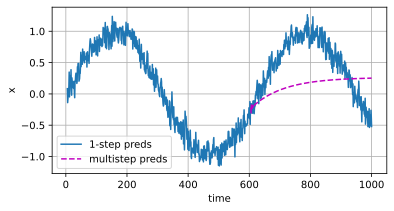

In [20]:
d2l.plot([data.time[data.tau:], data.time[data.num_train+data.tau:]],
         [onestep_preds, multistep_preds[data.num_train+data.tau:]], 'time',
         'x', legend=['1-step preds', 'multistep preds'], figsize=(6, 3))

Unfortunately, in this case we fail spectacularly.
The predictions decay to a constant
pretty quickly after a few steps.
Why did the algorithm perform so much worse
when predicting further into the future?
Ultimately, this is down to the fact
that errors build up.
Let's say that after step 1 we have some error $\epsilon_1 = \bar\epsilon$.
Now the *input* for step 2 is perturbed by $\epsilon_1$,
hence we suffer some error in the order of
$\epsilon_2 = \bar\epsilon + c \epsilon_1$
for some constant $c$, and so on.
The predictions can diverge rapidly
from the true observations.
You may already be familiar
with this common phenomenon.
For instance, weather forecasts for the next 24 hours
tend to be pretty accurate but beyond that,
accuracy declines rapidly.
We will discuss methods for improving this
throughout this chapter and beyond.

Let's [**take a closer look at the difficulties in $k$-step-ahead predictions**]
by computing predictions on the entire sequence for $k = 1, 4, 16, 64$.

遗憾的是，在这种情况下我们的预测结果惨不忍睹。预测在几步之后就会迅速衰减为一个常数。为什么当预测更远的未来时，算法的表现会差这么多？归根结底，这是由于误差会累积。假设在第1步后我们有某个误差$\epsilon_1 = \bar\epsilon$。现在第2步的*输入*会受到$\epsilon_1$的扰动，因此我们会遭受$\epsilon_2 = \bar\epsilon + c \epsilon_1$量级的误差（$c$为某个常数），依此类推。预测结果可能会迅速偏离真实观测。你可能已经对这个常见现象很熟悉。例如，未来24小时的天气预报往往相当准确，但超过这个范围后，准确性会迅速下降。我们将在本章和后续章节中讨论改进方法。

让我们通过计算在整个序列上$k = 1, 4, 16, 64$的预测，来[**仔细看看$k$步预测的困难**]。

In [25]:
def k_step_pred(k):
    features = []
    for i in range(data.tau):
        features.append(data.x[i : i+data.T-data.tau-k+1])
    # The (i+tau)-th element stores the (i+1)-step-ahead predictions
    for i in range(k):
        preds = model(torch.stack(features[i : i+data.tau], 1))
        features.append(preds.reshape(-1))
    return features[data.tau:]

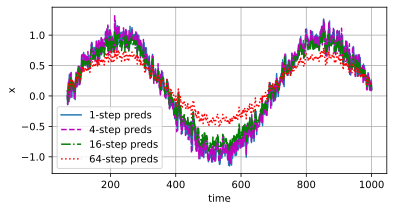

In [26]:
steps = (1, 4, 16, 64)
preds = k_step_pred(steps[-1])
d2l.plot(data.time[data.tau+steps[-1]-1:],
         [preds[k - 1].detach().numpy() for k in steps], 'time', 'x',
         legend=[f'{k}-step preds' for k in steps], figsize=(6, 3))

This clearly illustrates how the quality of the prediction changes
as we try to predict further into the future.
While the 4-step-ahead predictions still look good,
anything beyond that is almost useless.

## Summary

There is quite a difference in difficulty
between interpolation and extrapolation.
Consequently, if you have a sequence, always respect
the temporal order of the data when training,
i.e., never train on future data.
Given this kind of data,
sequence models require specialized statistical tools for estimation.
Two popular choices are autoregressive models
and latent-variable autoregressive models.
For causal models (e.g., time going forward),
estimating the forward direction is typically
a lot easier than the reverse direction.
For an observed sequence up to time step $t$,
its predicted output at time step $t+k$
is the $k$*-step-ahead prediction*.
As we predict further in time by increasing $k$,
the errors accumulate and the quality of the prediction degrades,
often dramatically.

## Exercises

1. Improve the model in the experiment of this section.
    1. Incorporate more than the past four observations? How many do you really need?
    1. How many past observations would you need if there was no noise? Hint: you can write $\sin$ and $\cos$ as a differential equation.
    1. Can you incorporate older observations while keeping the total number of features constant? Does this improve accuracy? Why?
    1. Change the neural network architecture and evaluate the performance. You may train the new model with more epochs. What do you observe?
1. An investor wants to find a good security to buy.
   They look at past returns to decide which one is likely to do well.
   What could possibly go wrong with this strategy?
1. Does causality also apply to text? To which extent?
1. Give an example for when a latent autoregressive model
   might be needed to capture the dynamic of the data.


这清楚地说明了当我们试图预测更远的未来时，预测质量如何变化。虽然4步预测的结果看起来还不错，但超过这个范围的预测几乎毫无用处。

## 小结

内插和外推在难度上有显著差别。因此，当使用序列数据进行训练时，始终要尊重数据的时序特性（即永远不要用未来的数据训练模型）。对于这类数据，序列模型需要专门的统计工具进行估计。两种常用选择是自回归模型和潜在变量自回归模型。对于因果模型（如时间的正向流动），正向方向的估计通常比反向方向容易得多。对于观测到时间步$t$为止的序列，其在时间步$t+k$的预测称为$k$*步预测*。随着我们通过增加$k$来预测更远的时间，误差会累积，预测质量通常会显著下降。

## 练习

1. 改进本节实验中的模型。
    1. 包含超过过去4个观测结果？你实际上需要多少个时间步？
    1. 如果没有噪声，需要多少个过去观测值？提示：可以将$\sin$和$\cos$写成微分方程。
    1. 能否在保持特征总数不变的情况下合并更旧的观测值？这能提高精度吗？为什么？
    1. 改变神经网络架构并评估性能。可以训练新模型更多轮次，观察结果如何？
1. 一位投资者想要找到一只值得购买的证券。他们会查看过去的回报率来决定哪种证券表现良好。这种策略可能会出什么问题？
1. 因果关系也适用于文本吗？适用程度如何？
1. 给出一个需要潜在自回归模型来捕捉数据动态的例子。

[Discussions](https://discuss.d2l.ai/t/114)
